<a href="https://colab.research.google.com/github/Rithanya77-05/rithanya-codebooster-2026/blob/main/Day-5/projectday5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
API_KEY = "b7f0cbab4168d4513821b9cf1d308c4"

In [10]:
cities = ["Chennai", "Mumbai", "Delhi", "Bangalore"]

In [11]:
import requests
import pandas as pd

# Your API Key
API_KEY = "74a4b330a7f4bf6743f688a910b6675d"

# Cities
cities = ["Chennai", "Mumbai", "Delhi", "Bangalore"]

# Empty list to store data
weather_data = []

# Loop through each city
for city in cities:

    # API URL
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    # Get response
    response = requests.get(url)

    # Convert to JSON
    data = response.json()

    # Check for API errors
    if data.get("cod") == 401:
        print(f"Error: Invalid API key for {city}. Please check your API_KEY.")
        break # Exit the loop if API key is invalid
    elif data.get("cod") == "404": # OpenWeatherMap returns '404' as a string for city not found
        print(f"Error: City '{city}' not found.")
        continue # Skip to the next city

    # Extract needed fields
    weather = {
        "city": data["name"],
        "temperature": data["main"]["temp"],
        "humidity": data["main"]["humidity"],
        "pressure": data["main"]["pressure"],
        "wind_speed": data["wind"]["speed"],
        "weather_condition": data["weather"][0]["main"]
    }

    # Add to list
    weather_data.append(weather)

# Convert list to DataFrame
df = pd.DataFrame(weather_data)

# Display data
print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17        59      1005        5.14            Clouds
1     Mumbai        34.99        55      1008        5.14             Smoke
2      Delhi        35.05        36      1005        3.09             Clear
3  Bengaluru        31.65        55      1009        5.81            Clouds


In [12]:
# Save dataset to CSV
df.to_csv("weather_data.csv", index=False)

print("CSV File Saved Successfully")

CSV File Saved Successfully


In [13]:
df = pd.read_csv("weather_data.csv")

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17        59      1005        5.14            Clouds
1     Mumbai        34.99        55      1008        5.14             Smoke
2      Delhi        35.05        36      1005        3.09             Clear
3  Bengaluru        31.65        55      1009        5.81            Clouds


In [14]:
# Add missing values manually
df.loc[1, "humidity"] = None
df.loc[2, "wind_speed"] = None

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17      59.0      1005        5.14            Clouds
1     Mumbai        34.99       NaN      1008        5.14             Smoke
2      Delhi        35.05      36.0      1005         NaN             Clear
3  Bengaluru        31.65      55.0      1009        5.81            Clouds


In [15]:
# Add duplicate row
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17      59.0      1005        5.14            Clouds
1     Mumbai        34.99       NaN      1008        5.14             Smoke
2      Delhi        35.05      36.0      1005         NaN             Clear
3  Bengaluru        31.65      55.0      1009        5.81            Clouds
4    Chennai        34.17      59.0      1005        5.14            Clouds


In [16]:
print(df.isnull().sum())

city                 0
temperature          0
humidity             1
pressure             0
wind_speed           1
weather_condition    0
dtype: int64


In [17]:
# Fill missing values using mean
df["humidity"].fillna(df["humidity"].mean(), inplace=True)

df["wind_speed"].fillna(df["wind_speed"].mean(), inplace=True)

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17     59.00      1005      5.1400            Clouds
1     Mumbai        34.99     52.25      1008      5.1400             Smoke
2      Delhi        35.05     36.00      1005      5.3075             Clear
3  Bengaluru        31.65     55.00      1009      5.8100            Clouds
4    Chennai        34.17     59.00      1005      5.1400            Clouds


In [18]:
print("Before removing duplicates:", df.shape)

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (5, 6)
After removing duplicates: (4, 6)


In [19]:
# Validate temperature
df = df[df["temperature"] > 0]

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition
0    Chennai        34.17     59.00      1005      5.1400            Clouds
1     Mumbai        34.99     52.25      1008      5.1400             Smoke
2      Delhi        35.05     36.00      1005      5.3075             Clear
3  Bengaluru        31.65     55.00      1009      5.8100            Clouds


In [20]:
df["heat_index"] = df["temperature"] + (0.1 * df["humidity"])

print(df)

        city  temperature  humidity  pressure  wind_speed weather_condition  \
0    Chennai        34.17     59.00      1005      5.1400            Clouds   
1     Mumbai        34.99     52.25      1008      5.1400             Smoke   
2      Delhi        35.05     36.00      1005      5.3075             Clear   
3  Bengaluru        31.65     55.00      1009      5.8100            Clouds   

   heat_index  
0      40.070  
1      40.215  
2      38.650  
3      37.150  


In [21]:
import sqlite3
# Create database connection
conn = sqlite3.connect("weather_database.db")

print("Database Connected Successfully")


Database Connected Successfully


In [22]:
# Store dataframe into SQL table
df.to_sql("weather_table", conn, if_exists="replace", index=False)

print("Data Stored Successfully")

Data Stored Successfully


In [23]:
query = "SELECT * FROM weather_table"

result = pd.read_sql(query, conn)

print(result)

        city  temperature  humidity  pressure  wind_speed weather_condition  \
0    Chennai        34.17     59.00      1005      5.1400            Clouds   
1     Mumbai        34.99     52.25      1008      5.1400             Smoke   
2      Delhi        35.05     36.00      1005      5.3075             Clear   
3  Bengaluru        31.65     55.00      1009      5.8100            Clouds   

   heat_index  
0      40.070  
1      40.215  
2      38.650  
3      37.150  


In [24]:
query = """
SELECT city, temperature
FROM weather_table
WHERE temperature > 33
"""

result = pd.read_sql(query, conn)

print(result)

      city  temperature
0  Chennai        34.17
1   Mumbai        34.99
2    Delhi        35.05


In [25]:
query = """
SELECT AVG(humidity) AS average_humidity
FROM weather_table
"""

result = pd.read_sql(query, conn)

print(result)

   average_humidity
0           50.5625


In [26]:
query = """
SELECT city, MAX(temperature) AS highest_temperature
FROM weather_table
"""

result = pd.read_sql(query, conn)

print(result)

    city  highest_temperature
0  Delhi                35.05


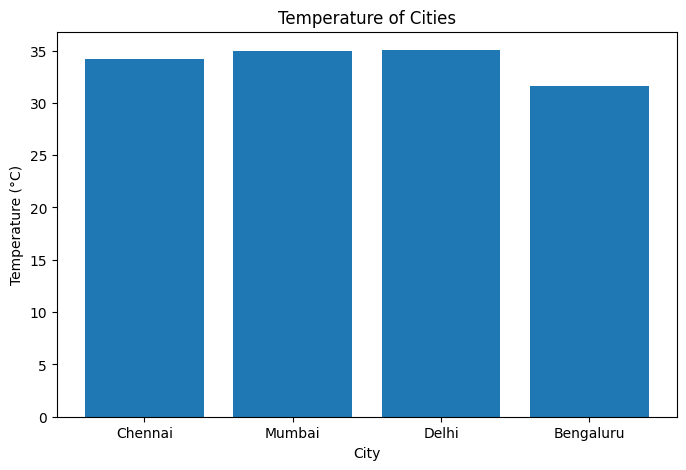

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

plt.bar(df["city"], df["temperature"])

plt.title("Temperature of Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

plt.show()

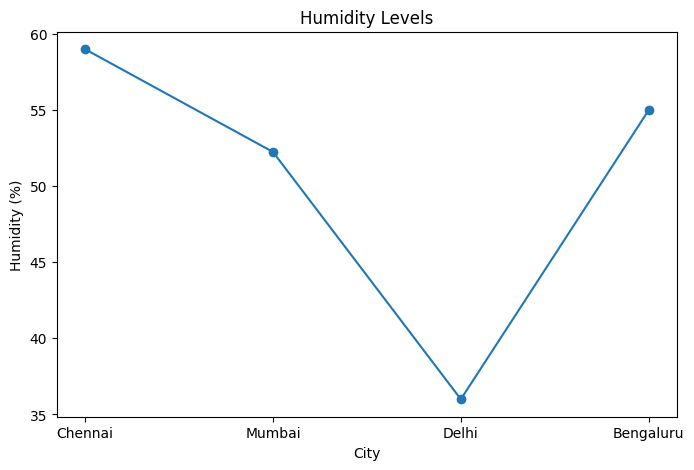

In [29]:
plt.figure(figsize=(8,5))

plt.plot(df["city"], df["humidity"], marker='o')

plt.title("Humidity Levels")
plt.xlabel("City")
plt.ylabel("Humidity (%)")

plt.show()

weather_condition
Clouds    2
Smoke     1
Clear     1
Name: count, dtype: int64


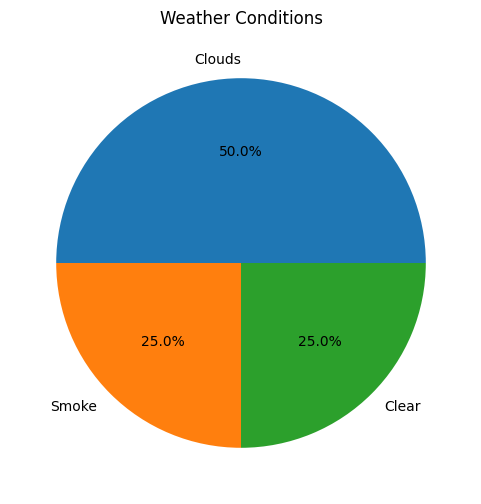

In [30]:
weather_counts = df["weather_condition"].value_counts()

print(weather_counts)
plt.figure(figsize=(6,6))

plt.pie(weather_counts,
        labels=weather_counts.index,
        autopct='%1.1f%%')

plt.title("Weather Conditions")

plt.show()

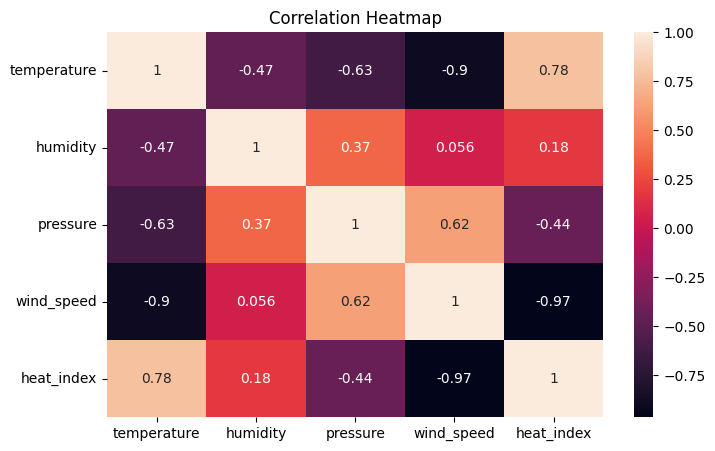

In [31]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["temperature", "humidity", "pressure", "wind_speed", "heat_index"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [33]:
X = df[["temperature", "pressure", "wind_speed"]]
y = df["humidity"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")
predictions = model.predict(X_test)

print(predictions)
comparison = pd.DataFrame({
    "Actual Humidity": y_test,
    "Predicted Humidity": predictions
})

print(comparison)
error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)
new_data = [[32, 1008, 5]]

prediction = model.predict(new_data)

print("Predicted Humidity:", prediction[0])

Model Trained Successfully
[40.44033939]
   Actual Humidity  Predicted Humidity
1            52.25           40.440339
Mean Absolute Error: 11.809660608518698
Predicted Humidity: 95.29746516890282
